In [1]:
!pip install -q transformers==4.44.2 datasets accelerate evaluate scikit-learn matplotlib

import os
import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve, auc
from transformers import AutoTokenizer, AutoModelForCausalLM
from google.colab import drive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 135.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 130.2 MB/s eta 0:00:00


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_PATH = "/content/drive/MyDrive/Research Code and Data/"
PROCESSED_PATH = BASE_PATH + "data_processed/"
SPLIT_PATH = PROCESSED_PATH + "splits/"
RESULTS_PATH = BASE_PATH + "results/llama_final/"

os.makedirs(RESULTS_PATH, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [6]:
from huggingface_hub import login
login()

In [7]:
MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [8]:
def build_chat_prompt(text):

    messages = [
        {"role": "system", "content": "You are a hate speech detection system."},
        {"role": "user", "content":
         f"""Classify the following text strictly as either:
Hate
or
Not Hate

Text:
{text}

Answer with only one label."""}
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

In [9]:
def predict_with_probability(text):

    prompt = build_chat_prompt(text)

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[:, -1, :]
    probs = torch.softmax(logits, dim=-1)

    hate_id = tokenizer(" Hate", add_special_tokens=False)["input_ids"][0]
    not_id  = tokenizer(" Not", add_special_tokens=False)["input_ids"][0]

    hate_prob = probs[0][hate_id].item()
    not_prob  = probs[0][not_id].item()

    if hate_prob > not_prob:
        return 1, hate_prob
    else:
        return 0, hate_prob

In [10]:
def evaluate_dataset(dataset_name):

    print(f"\n======== Zero-Shot Mistral on {dataset_name.upper()} ========\n")

    test_df = pd.read_csv(f"{SPLIT_PATH}{dataset_name}_test.csv")

    test_df = test_df.dropna(subset=["text", "label"])
    test_df["text"] = test_df["text"].astype(str)
    test_df = test_df[test_df["text"].str.strip() != ""]
    test_df = test_df.reset_index(drop=True)

    true_labels = []
    pred_labels = []
    probabilities = []

    start_time = time.time()

    for text, label in zip(test_df["text"], test_df["label"]):
        pred, prob = predict_with_probability(text)

        true_labels.append(label)
        pred_labels.append(pred)
        probabilities.append(prob)

    runtime = time.time() - start_time

    acc = accuracy_score(true_labels, pred_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, pred_labels, average="binary"
    )

    roc_auc = roc_auc_score(true_labels, probabilities)

    fpr, tpr, _ = roc_curve(true_labels, probabilities)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC - LLaMA Zero-Shot - {dataset_name}")
    plt.legend()
    plt.show()

    return {
        "dataset": dataset_name,
        "eval_accuracy": acc,
        "eval_precision": precision,
        "eval_recall": recall,
        "eval_f1": f1,
        "eval_roc_auc": roc_auc,
        "runtime_seconds": runtime
    }


======== Zero-Shot Mistral on THAR ========



We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


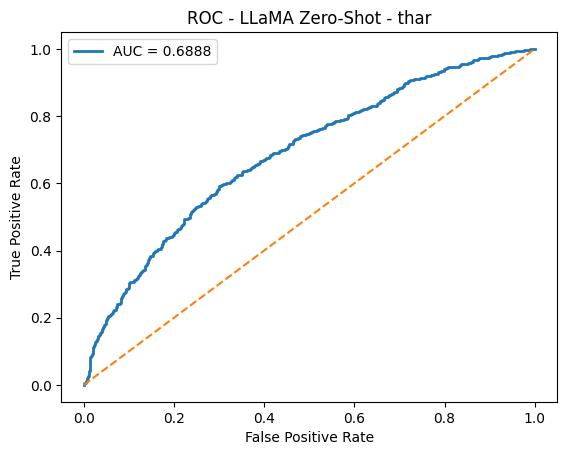


======== Zero-Shot Mistral on HASOC ========



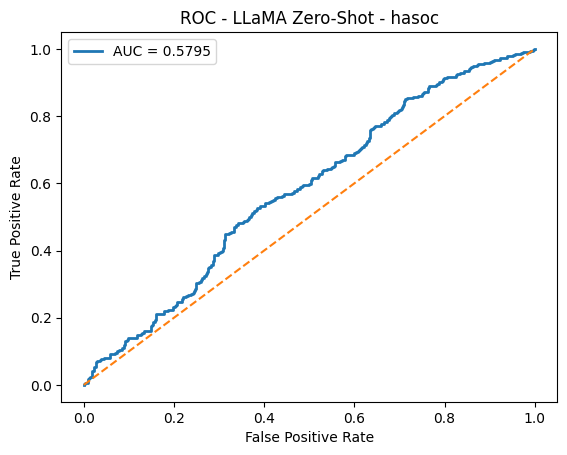


======== Zero-Shot Mistral on AOLD ========



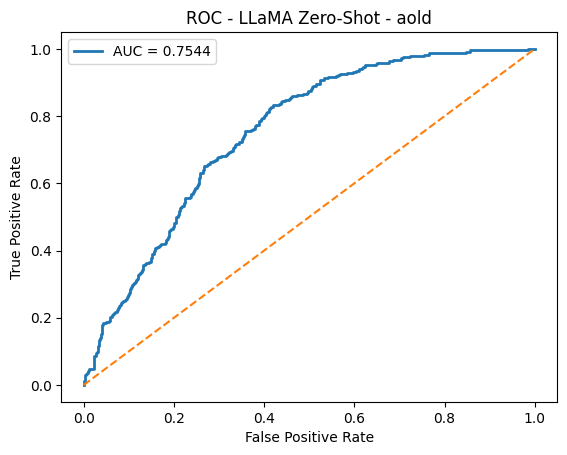


======== Zero-Shot Mistral on COMBINED ========



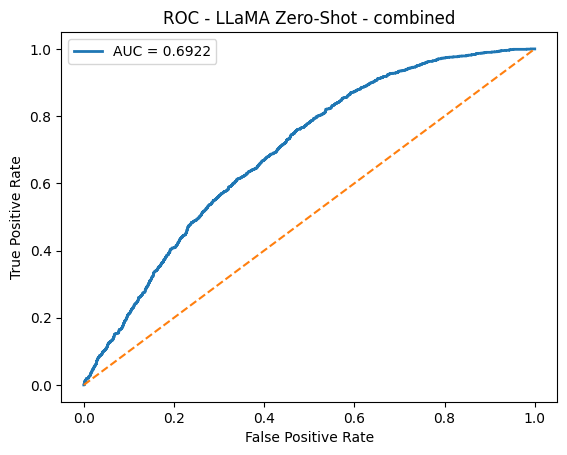

In [11]:
datasets = ["thar", "hasoc", "aold", "combined"]

summary = []

for ds in datasets:
    result = evaluate_dataset(ds)
    summary.append(result)

In [12]:
results_df = pd.DataFrame(summary)
results_df.to_csv(RESULTS_PATH + "llama_final_results.csv", index=False)

results_df

,dataset,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc,runtime_seconds
0,thar,0.531178,0.501918,0.959658,0.659110,0.688774,71.178979
1,hasoc,0.551793,0.526564,0.901010,0.664680,0.579480,37.585522
2,aold,0.604132,0.420290,0.891061,0.571173,0.754426,45.105210
3,combined,0.565526,0.493038,0.932934,0.645135,0.692163,147.337373


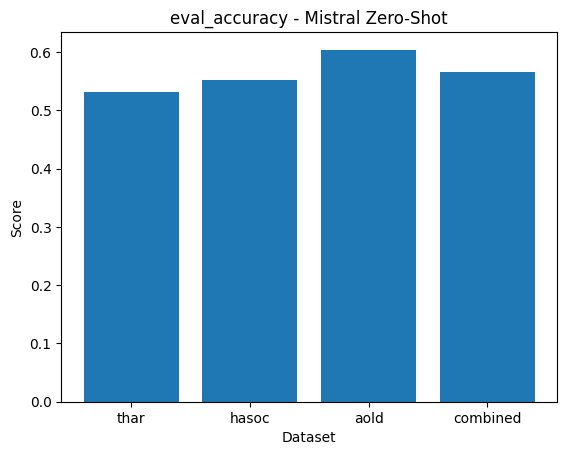

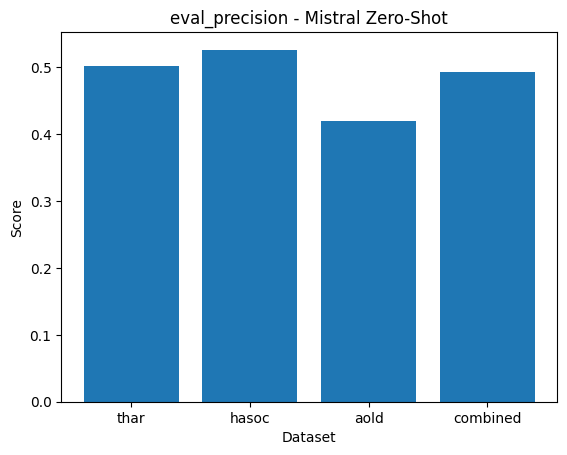

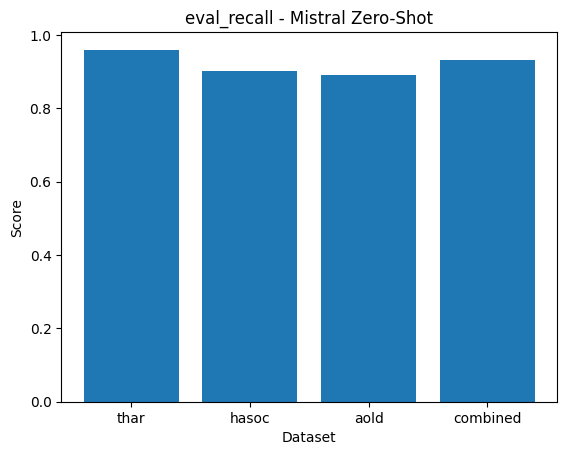

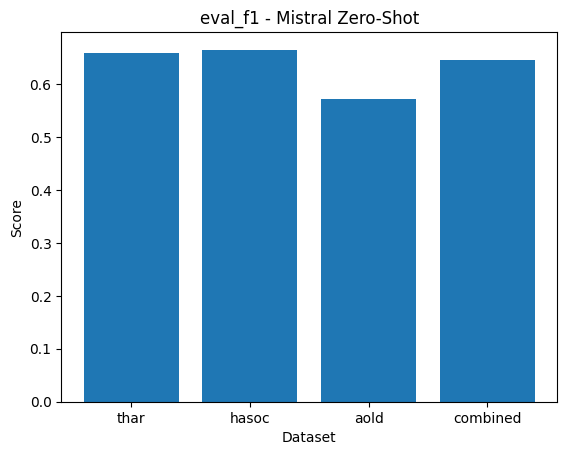

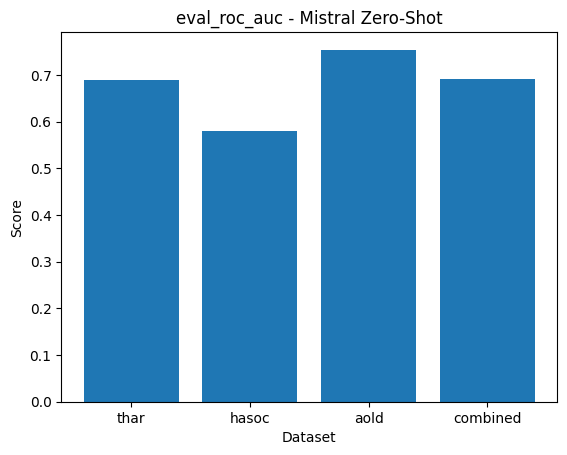

In [13]:
metrics_to_plot = [
    "eval_accuracy",
    "eval_precision",
    "eval_recall",
    "eval_f1",
    "eval_roc_auc"
]

for metric in metrics_to_plot:
    plt.figure()
    plt.bar(results_df["dataset"], results_df[metric])
    plt.title(metric + " - Mistral Zero-Shot")
    plt.ylabel("Score")
    plt.xlabel("Dataset")
    plt.show()